# EDA

# Modelo 1

# Modelo 2


## Importación de librerías

In [1]:
import sys
import pathlib
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga de Datos

In [2]:

# 1. Definir la ruta base donde se encuentra este notebook
# .resolve().parent apunta a la carpeta 'notebooks'
base_path = pathlib.Path().resolve().parent

# 2. Construir la ruta hacia el CSV usando los nombres de las carpetas
# Esto une automáticamente las carpetas con / o \ según el sistema operativo
data_path = base_path / "data" / "raw" / "Reportes" / "Estadisticas OIJ.csv"

# 3. Cargar el archivo
try:
    df = pd.read_csv(data_path)
    print("Archivo cargado exitosamente desde:", data_path)
except FileNotFoundError:
    print(f"Error: No se encontró el archivo en {data_path}")
    print("Verifica que la carpeta 'data' esté al mismo nivel que la carpeta 'notebooks'.")

df.head()

Archivo cargado exitosamente desde: C:\Users\kenda\Downloads\SmartCityIA-main (1)\SmartCityIA-main\data\raw\Reportes\Estadisticas OIJ.csv


,Delito,SubDelito,Fecha,Rango Horario,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton
0,ASALTO,ARMA BLANCA,01/02/2022,12:00:00 - 14:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ASERRI
1,ASALTO,ARMA BLANCA,03/02/2022,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA
2,ASALTO,ARMA BLANCA,04/02/2022,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,06/02/2022,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,08/02/2022,00:00:00 - 02:59:59,PERSONA,TURISTA/EXTRANJERO [PERSONA],Mayor de edad,HOMBRE,RUSIA,PUNTARENAS,GARABITO


## Limpieza de datos

In [3]:
df.columns = df.columns.str.strip()

df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True, errors='coerce')

cols_texto = ["Delito", "SubDelito", "Provincia", "Canton", "Sexo"]
for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()


cols_texto = ["Delito", "SubDelito", "Provincia", "Canton", "Sexo", "Edad"]

for col in cols_texto:
    df[col] = df[col].astype(str).str.strip().str.upper()

# 2. ELIMINA o comenta esta línea, ya que no son números:
# df["Edad"] = pd.to_numeric(df["Edad"], errors='coerce')

df = df.dropna(subset=["Fecha", "Delito"])

print("\nDatos después de limpieza:")
df.info()
df = df.map(lambda x: str(x).strip().upper() if isinstance(x, str) else x)
df = df[~df.isin(["DESCONOCIDO"]).any(axis=1)]

print("Nuevo tamaño del dataset:", df.shape)


Datos después de limpieza:
<class 'pandas.DataFrame'>
RangeIndex: 173432 entries, 0 to 173431
Data columns (total 11 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Delito         173432 non-null  str           
 1   SubDelito      173432 non-null  str           
 2   Fecha          173432 non-null  datetime64[us]
 3   Rango Horario  173432 non-null  str           
 4   Victima        173432 non-null  str           
 5   SubVictima     173432 non-null  str           
 6   Edad           173432 non-null  str           
 7   Sexo           173432 non-null  str           
 8   Nacionalidad   173432 non-null  str           
 9   Provincia      173432 non-null  str           
 10  Canton         173432 non-null  str           
dtypes: datetime64[us](1), str(10)
memory usage: 14.6 MB
Nuevo tamaño del dataset: (163432, 11)


## Analisis General

In [4]:
print("\nTop delitos:")
print(df["Delito"].value_counts().head(10))

print("\nTop provincias:")
print(df["Provincia"].value_counts())


Top delitos:
Delito
HURTO                54817
ASALTO               41005
ROBO                 31929
ROBO DE VEHICULO     18392
TACHA DE VEHICULO    14562
HOMICIDIO             2727
Name: count, dtype: int64

Top provincias:
Provincia
SAN JOSE      62260
ALAJUELA      26068
PUNTARENAS    19386
GUANACASTE    15708
LIMON         14424
HEREDIA       13592
CARTAGO       11994
Name: count, dtype: int64


## Delitos mas frecuentes

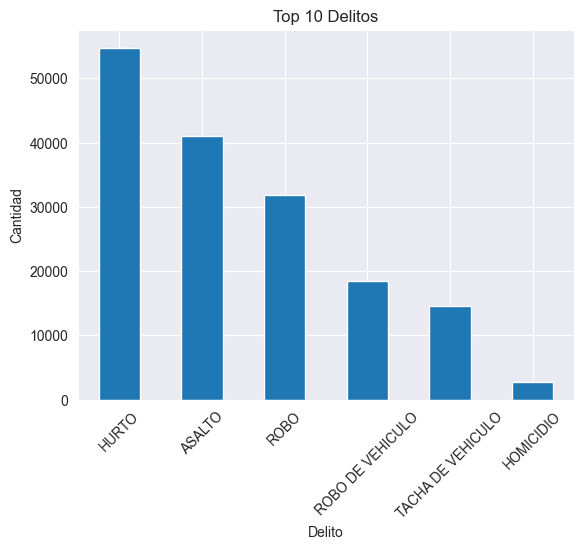

In [5]:
top_delitos = df["Delito"].value_counts().head(10)

plt.figure()
top_delitos.plot(kind='bar')
plt.title("Top 10 Delitos")
plt.xlabel("Delito")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

## Analisis por genero

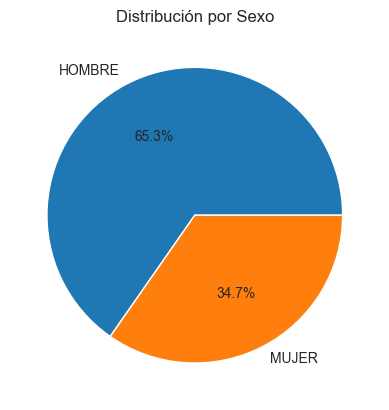

In [6]:
sexo_counts = df["Sexo"].value_counts()

plt.figure()
sexo_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Distribución por Sexo")
plt.ylabel("")
plt.show()

## Top Provincias

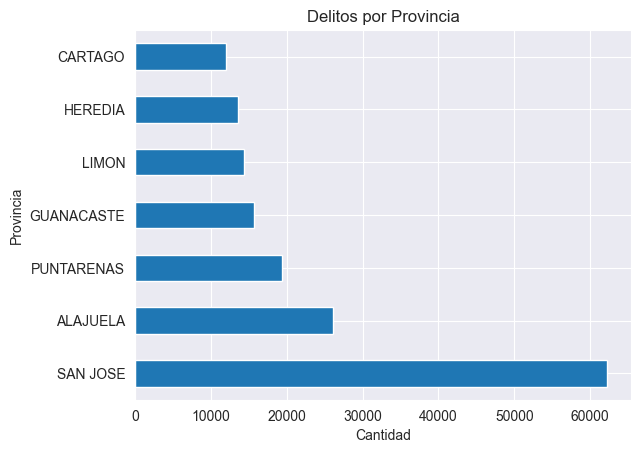

In [7]:
prov_counts = df["Provincia"].value_counts()

plt.figure()
prov_counts.plot(kind='barh')
plt.title("Delitos por Provincia")
plt.xlabel("Cantidad")
plt.show()

## Conclusiones

In [8]:
print("\n Conclusiones")

print("Delito más común:", df["Delito"].value_counts().idxmax())
print("Provincia con más delitos:", df["Provincia"].value_counts().idxmax())
print("Genero con más delitos:", df["Sexo"].value_counts().idxmax())


 Conclusiones
Delito más común: HURTO
Provincia con más delitos: SAN JOSE
Genero con más delitos: HOMBRE


## Guardar datos limpios

In [9]:
base_path = pathlib.Path().resolve().parent
save_path = base_path / "data" / "processed" / "delitos_limpios.csv"

save_path.parent.mkdir(parents=True, exist_ok=True)

# 3. Guardar el DataFrame
# index=False evita que se cree una columna extra con los números de fila
df.to_csv(save_path, index=False, encoding='utf-8')

print(f"Dataset guardado exitosamente en: {save_path}")
print(f"Finalizado con {df.shape[0]} registros y {df.shape[1]} columnas.")

Dataset guardado exitosamente en: C:\Users\kenda\Downloads\SmartCityIA-main (1)\SmartCityIA-main\data\processed\delitos_limpios.csv
Finalizado con 163432 registros y 11 columnas.
